# Day 7: Session 7A - The Anatomy of a Figure

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7a_matplotlib.html)

Date: 09/09/2026

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://eds-217-essential-python.github.io/data/toolik_weather.csv'
toolik = pd.read_csv(url)

toolik['date'] = pd.to_datetime(toolik['Date'], format='%Y%m%d')
toolik['year'] = toolik['date'].dt.year
toolik['month'] = toolik['date'].dt.month

toolik.shape

(11171, 24)

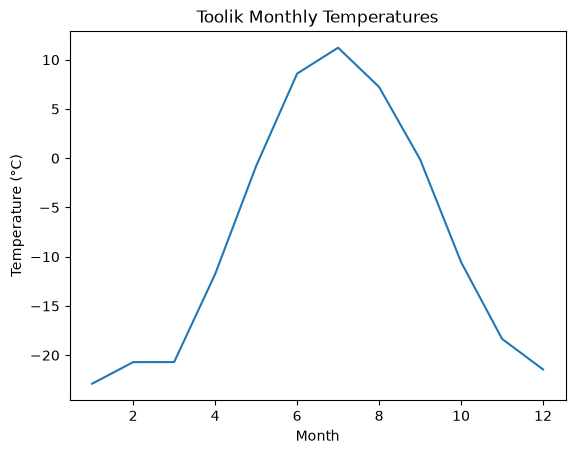

In [12]:
monthly_means = toolik.groupby('month')['Daily_AirTemp_Mean_C'].mean()

plt.plot(monthly_means)
plt.title('Toolik Monthly Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

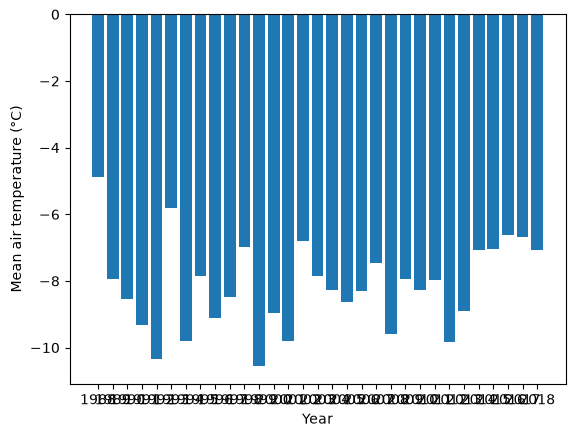

In [13]:
annual_means = toolik.groupby('year')['Daily_AirTemp_Mean_C'].mean()

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.show()

this figure is mostly unreadable due to wrong aspect ratio.  fix using the figsize= argument in plt.figure()

plt.figure(figsize=(width, height))

                   ↑       ↑
                   
                 inches  inches

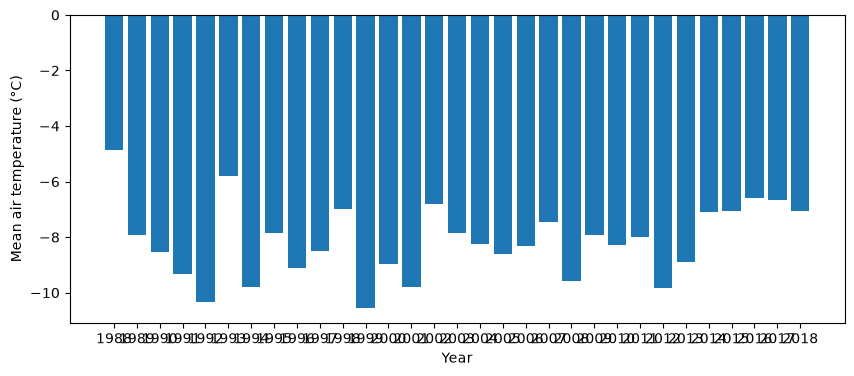

In [14]:
plt.figure(figsize=(10, 4))

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.show()

Tick labels that do not fit - rotate them!

plt.xticks(rotation=45, ha='right')

ha is "horizontal alignment"

see below:



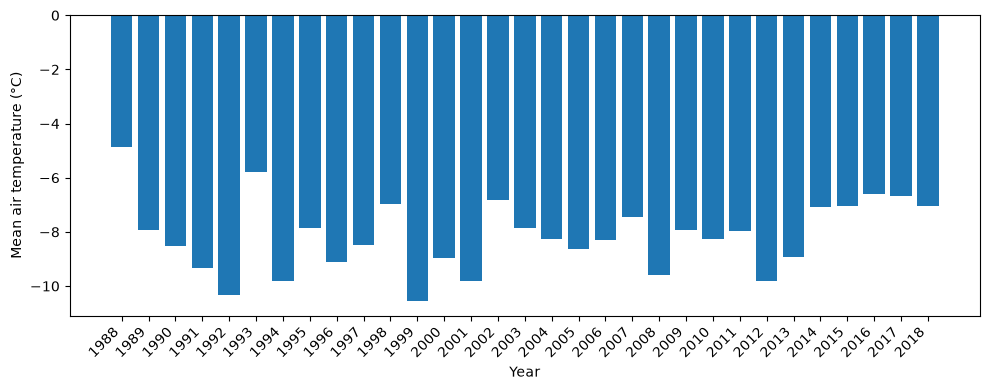

In [15]:
plt.figure(figsize=(10, 4))

plt.bar(annual_means.index.astype(str), annual_means)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.tight_layout()
plt.show()

plt.tight_layout() resizes axes so that everything fits

### Test your knowledge
Build a Series holding the number of non-null Daily_Precip_Total_mm readings in each year, using .count() on a grouping by year. Draw it as bars in a figure ten inches wide and four tall, with the year labels rotated 45 degrees, and finish the cell with plt.tight_layout(). Label both axes and title it.

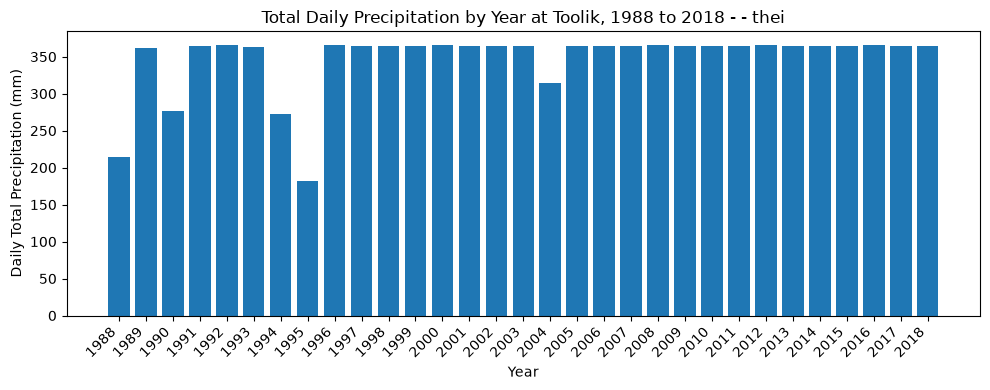

In [16]:
precip_series = toolik.groupby('year')['Daily_Precip_Total_mm'].count()

plt.figure(figsize=(10, 4))

plt.bar(precip_series.index.astype(str), precip_series)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year')
plt.ylabel('Daily Total Precipitation (mm)')
plt.title("Total Daily Precipitation by Year at Toolik, 1988 to 2018 - - thei")
plt.tight_layout()
plt.show()


### labels are not decoration
Every figure needs three things:

plt.xlabel('what is along the bottom, with units')

plt.ylabel('what is up the side, with units')

plt.title('what this figure is of')

### plotting toolik data

In [17]:
early = toolik[toolik['year'] <= 1998]
late = toolik[toolik['year'] >= 2009]

comparison = pd.DataFrame({
    'early': early.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
    'late': late.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
})

comparison['change'] = comparison['late'] - comparison['early']

comparison.round(2)

,early,late,change
month,,,
1,-24.72,-21.26,3.46
2,-21.86,-19.38,2.48
3,-18.62,-20.64,-2.02
4,-10.40,-11.86,-1.45
5,0.37,-0.54,-0.91
6,8.43,8.19,-0.24
7,12.05,11.28,-0.77
8,7.48,7.18,-0.30
9,-0.85,-0.01,0.84


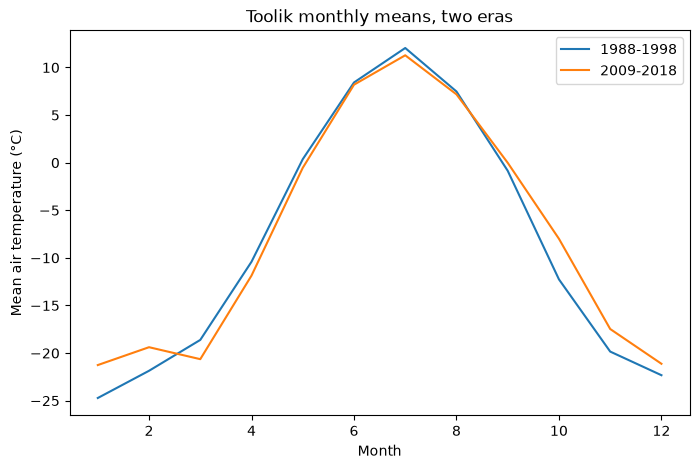

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index, comparison['early'], label='1988-1998')
plt.plot(comparison.index, comparison['late'], label='2009-2018')

plt.xlabel('Month')
plt.ylabel('Mean air temperature (°C)')
plt.title('Toolik monthly means, two eras')
plt.legend()
plt.show()

general format:

plt.plot(x, y, label='what this line is') -----> once per series

plt.legend() -------> once per figure

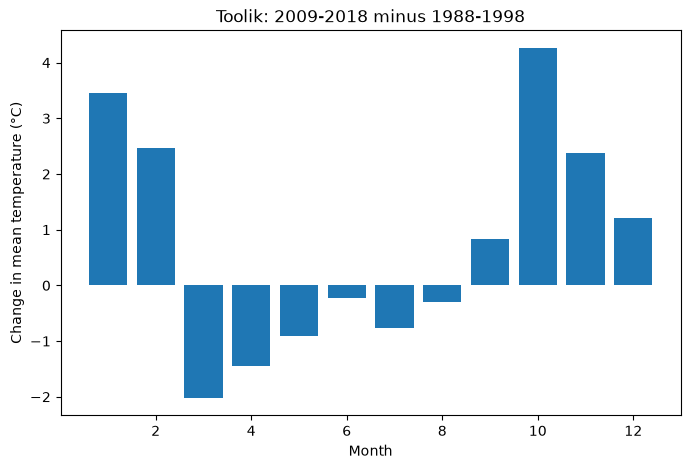

In [19]:
# plotting JUST the change/difference (separate from the normal seasonal cycle)

plt.figure(figsize=(8, 5))

plt.bar(comparison.index, comparison['change'])

plt.xlabel('Month')
plt.ylabel('Change in mean temperature (°C)')
plt.title('Toolik: 2009-2018 minus 1988-1998')
plt.show()

### points instead of lines:

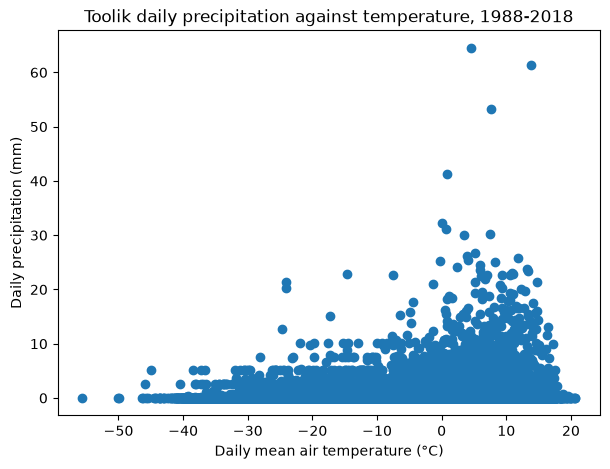

In [20]:
wet_days = toolik.dropna(subset=['Daily_Precip_Total_mm'])

plt.figure(figsize=(7, 5))

plt.scatter(wet_days['Daily_AirTemp_Mean_C'], wet_days['Daily_Precip_Total_mm'])
# plt.scatter is the key here

plt.xlabel('Daily mean air temperature (°C)')
plt.ylabel('Daily precipitation (mm)')
plt.title('Toolik daily precipitation against temperature, 1988-2018')
plt.show()

### Key points

- Every matplotlib picture is a figure (the canvas) containing an axes (where the data goes)

- plt.figure(figsize=(width, height)) sets the canvas size in inches, and must come before the plotting call.

- Plotting commands with no plt.figure() between them stack on the same axes. Stacking is a feature when you want two series in one picture and a bug when you do not.

- Always label: plt.xlabel(), plt.ylabel(), plt.title(), with units in the axis labels.

- Two series on one axes need a label= on each and one plt.legend() call.

- plt.xticks(rotation=45, ha='right') rescues crowded tick labels.

- plt.tight_layout() goes last, and stops matplotlib cropping what you rotated.

- plt.plot() connects points in order and is for ordered x-axes. plt.scatter() is for one measurement against another.

- A correct figure can still be useless. If your quantity of interest is a small difference, compute the difference and plot that.
